In [3]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install lightgbm
!pip install joblib
!pip install shap
!pip install jupyter

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("altruistdelhite04/loan-prediction-problem-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-prediction-problem-dataset' dataset.
Path to dataset files: /kaggle/input/loan-prediction-problem-dataset


In [6]:
import os
import pandas as pd

df = pd.read_csv(os.path.join(path, 'train_u6lujuX_CVtuZ9i.csv'))

print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [7]:
# Numerical columns

df["LoanAmount"] = df["LoanAmount"].fillna(
    df["LoanAmount"].median()
)

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(
    df["Loan_Amount_Term"].median()
)

# Categorical columns

categorical_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed",
    "Credit_History"
]

for col in categorical_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [8]:
df["TotalIncome"] = (
    df["ApplicantIncome"] +
    df["CoapplicantIncome"]
)

df["LoanIncomeRatio"] = (
    df["LoanAmount"] /
    (df["TotalIncome"] + 1)
)

df["EMI_Burden"] = (
    df["LoanAmount"] /
    df["Loan_Amount_Term"]
)

df["Dependents"] = df["Dependents"].replace(
    "3+",
    "3"
)

df["Dependents"] = df["Dependents"].astype(int)

df["IncomePerDependent"] = (
    df["TotalIncome"] /
    (df["Dependents"] + 1)
)



In [9]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanIncomeRatio,EMI_Burden,IncomePerDependent
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,0.021880,0.355556,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,0.021011,0.355556,3045.5
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0.021993,0.183333,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,0.024282,0.333333,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,0.023496,0.391667,6000.0


In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

label_cols = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in label_cols:
    df[col] = encoder.fit_transform(
        df[col]
    )



In [11]:
df.drop(
    columns=["Loan_ID"],
    inplace=True
)

In [12]:
y = df["Loan_Status"]
X = df.drop(
    columns=["Loan_Status"]
)
print(X.shape)
print(y.shape)

(614, 15)
(614,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
print(X_train.shape)
print(X_test.shape)

(491, 15)
(123, 15)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [16]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanIncomeRatio,EMI_Burden,IncomePerDependent
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,0.021880,0.355556,5849.0
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,0.021011,0.355556,3045.5
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,0.021993,0.183333,3000.0
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,0.024282,0.333333,4941.0
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,0.023496,0.391667,6000.0


In [17]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(491, 15)
(123, 15)
Loan_Status
1    337
0    154
Name: count, dtype: int64
Loan_Status
1    85
0    38
Name: count, dtype: int64


In [18]:
# logistics regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(
    X_test_scaled
)

lr_prob = lr_model.predict_proba(
    X_test_scaled
)[:,1]

In [19]:
# random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

In [20]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(
    name,
    y_true,
    y_pred,
    y_prob
):
    print(f"\n{name}")
    print("-"*40)

    print(
        "Accuracy:",
        round(
            accuracy_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "Precision:",
        round(
            precision_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "F1:",
        round(
            f1_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "ROC-AUC:",
        round(
            roc_auc_score(
                y_true,
                y_prob
            ),
            4
        )
    )

In [23]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)


Logistic Regression
----------------------------------------
Accuracy: 0.8618
Precision: 0.84
Recall: 0.9882
F1: 0.9081
ROC-AUC: 0.831

Random Forest
----------------------------------------
Accuracy: 0.8618
Precision: 0.8696
Recall: 0.9412
F1: 0.904
ROC-AUC: 0.8342

XGBoost
----------------------------------------
Accuracy: 0.8211
Precision: 0.8462
Recall: 0.9059
F1: 0.875
ROC-AUC: 0.8272


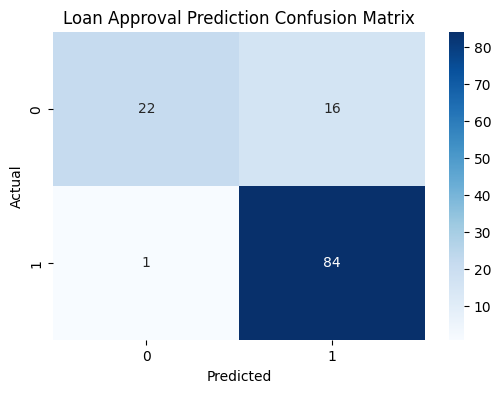

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Loan Approval Prediction Confusion Matrix")

plt.show()

In [25]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(lr_model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
9,Credit_History,1.238687
1,Married,0.252968
3,Education,0.169300
6,CoapplicantIncome,0.160765
12,LoanIncomeRatio,0.156981
14,IncomePerDependent,0.116597
7,LoanAmount,0.099932
0,Gender,0.098634
4,Self_Employed,0.088828
2,Dependents,0.072850


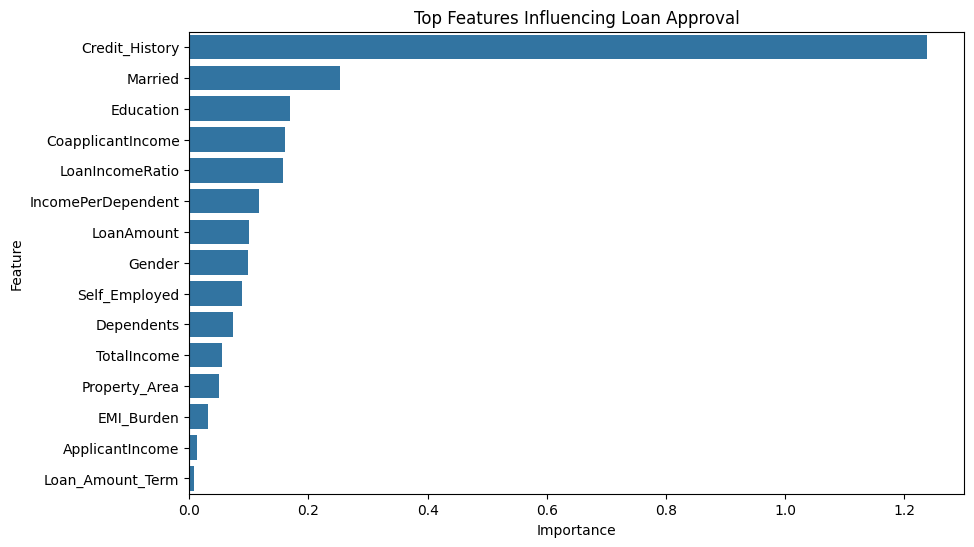

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(16)
)

plt.title("Top Features Influencing Loan Approval")
plt.show()

In [29]:
import shap

explainer = shap.LinearExplainer(
    lr_model,
    X_train_scaled
)

shap_values = explainer.shap_values(
    X_test_scaled
)

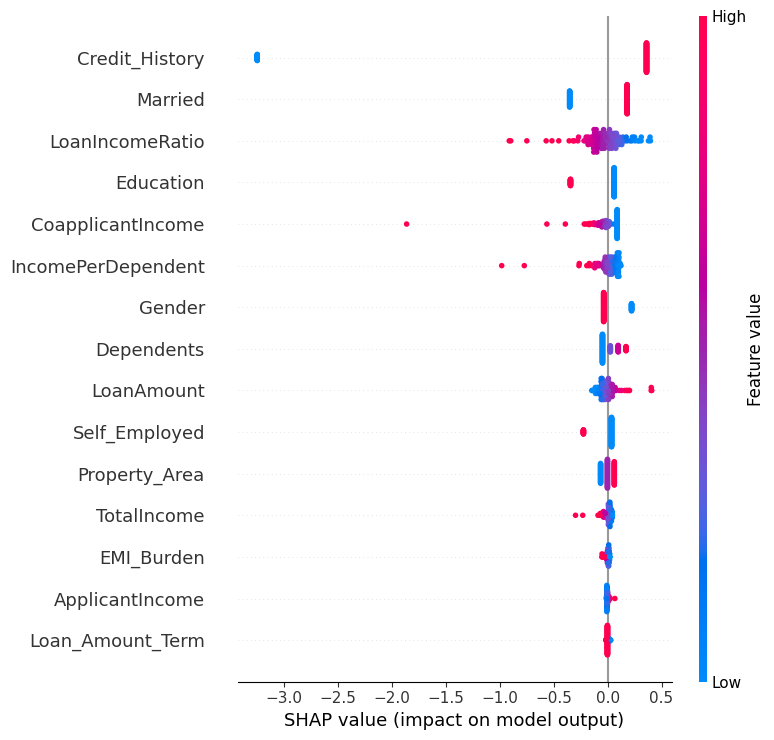

In [30]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

In [31]:
import joblib

joblib.dump(
    lr_model,
    "loan_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

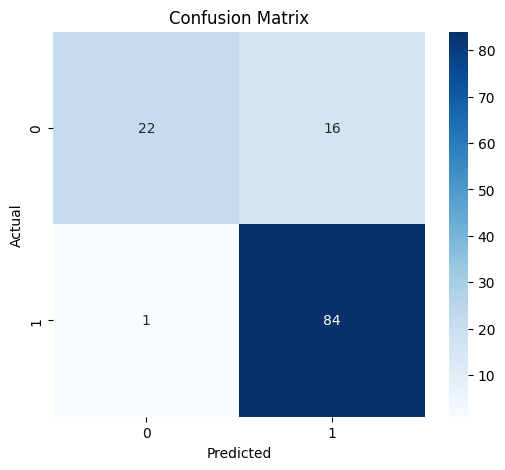

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()